In [1]:
# ==============================================================================
# PIPELINE 5: ML Preprocessing (Outliers, Log-Transformation & Setup)
# ==============================================================================
import pandas as pd

from src.profiling import generate_minimal_report
from src.merged_preparation import (
    remove_logical_errors,
    remove_extreme_outliers,
    winsorize_features,
    apply_log1p_transformation,
    encode_categorical_features,
    impute_missing_features
)
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Loading Golden Dataset from Pipeline 4...")
df_ml = pd.read_parquet("data/prepared/ted_combined.parquet")
print(f"Initial shape: {df_ml.shape}")

Loading Golden Dataset from Pipeline 4...
Initial shape: (2433720, 27)


In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Logical Cleaning & Outlier Handling
# ------------------------------------------------------------------------------

# 1.1 Logical Errors: Drop impossible negative values in time and money
logical_check_cols = [
    'PREPARATION_DAYS', 
    'DURATION', 
    'TARGET_AWARD_VALUE_EUR', 
    'LOT_AWARD_VALUE_EUR', 
    'ESTIMATED_VALUE_EUR',
    'NUMBER_OF_TENDERS'
]
df_ml = remove_logical_errors(df_ml, columns=logical_check_cols, min_val=0.0)

# 1.2 Trimming: Drop rows with completely corrupted target values (Top 0.1%)
target_outlier_cols = [
    'TARGET_AWARD_VALUE_EUR', 
    'LOT_AWARD_VALUE_EUR', 
    'NUMBER_OF_TENDERS'
]
df_ml = remove_extreme_outliers(df_ml, columns=target_outlier_cols, upper_quantile=0.999)

# 1.3 Winsorizing: Cap extreme input variables (Top 1%)
input_outlier_cols = [
    'LOTS_NUMBER', 
    'DURATION', 
    'ESTIMATED_VALUE_EUR', 
    'PREPARATION_DAYS',
    'NUTS_REGION_COUNT'
]
df_ml = winsorize_features(df_ml, columns=input_outlier_cols, upper_quantile=0.99)

Removing logical errors (Dropping values < 0.0)...
 -> Dropped 10 rows with impossible negative values.
Applying quantile trimming (Dropping top 0.10%)...
 -> Dropped 6,108 rows containing extreme upper outliers.
Winsorizing features (Capping at the 99.0th percentile)...
  -> LOTS_NUMBER: Capped 23,753 extreme values at 553.00.
  -> DURATION: Capped 20,799 extreme values at 72.00.
  -> ESTIMATED_VALUE_EUR: Capped 14,010 extreme values at 135,985,223.98.
  -> PREPARATION_DAYS: Capped 23,050 extreme values at 70.00.
  -> NUTS_REGION_COUNT: Capped 20,735 extreme values at 2.00.


Applying log1p transformation (Overwriting original columns)...
  -> Log-transformed: TARGET_AWARD_VALUE_EUR
  -> Log-transformed: LOT_AWARD_VALUE_EUR
  -> Log-transformed: ESTIMATED_VALUE_EUR
  -> Log-transformed: NUMBER_OF_TENDERS
  -> Log-transformed: LOTS_NUMBER
  -> Log-transformed: DURATION
  -> Log-transformed: PREPARATION_DAYS
  -> Log-transformed: NUTS_REGION_COUNT


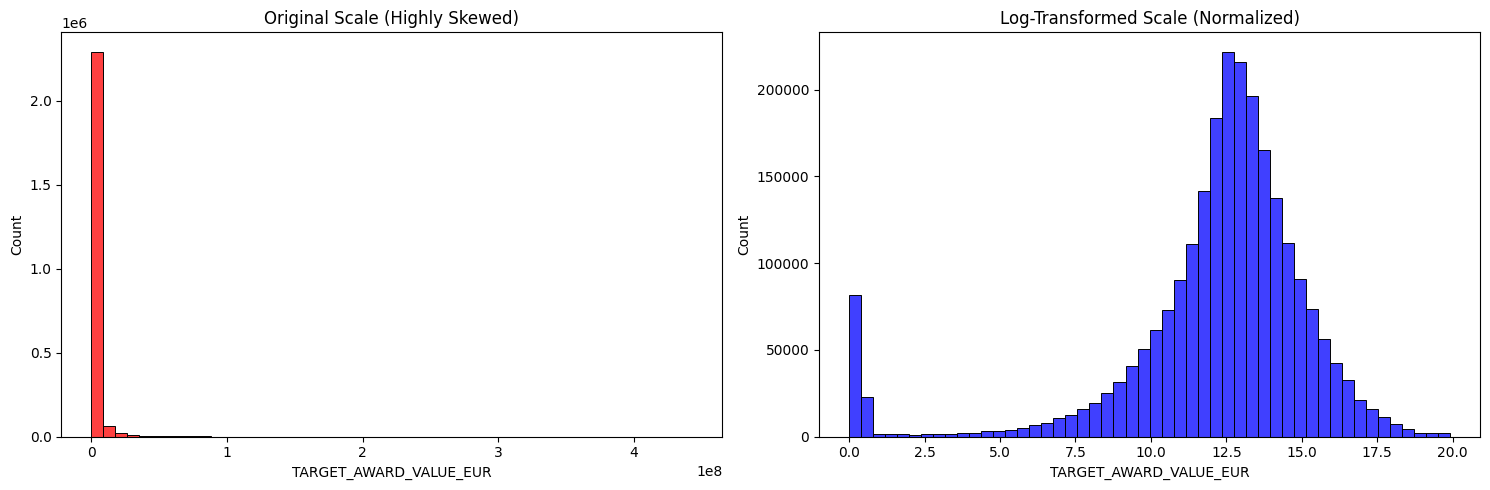

In [3]:
# ------------------------------------------------------------------------------
# STEP 2: Normalization (Log-Transformation In-Place)
# ------------------------------------------------------------------------------
cols_to_log = [
    'TARGET_AWARD_VALUE_EUR', 
    'LOT_AWARD_VALUE_EUR', 
    'ESTIMATED_VALUE_EUR', 
    'NUMBER_OF_TENDERS', 
    'LOTS_NUMBER',
    'DURATION',
    'PREPARATION_DAYS',
    'NUTS_REGION_COUNT'
]

# Create a copy of original prices BEFORE transformation for plotting purposes
prices_original = df_ml['TARGET_AWARD_VALUE_EUR'].copy()

# Apply Transformation (Overwrites original columns)
df_ml = apply_log1p_transformation(df_ml, columns=cols_to_log)

# Let's visualize the impact of the normalization!
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(prices_original, bins=50, ax=axes[0], color='red')
axes[0].set_title('Original Scale (Highly Skewed)')

sns.histplot(df_ml['TARGET_AWARD_VALUE_EUR'], bins=50, ax=axes[1], color='blue')
axes[1].set_title('Log-Transformed Scale (Normalized)')

plt.tight_layout()
plt.show()

In [4]:
# ------------------------------------------------------------------------------
# STEP 3: Categorical Encoding (Label Encoding for Tree-Based Models)
# ------------------------------------------------------------------------------
from src.merged_preparation import encode_categorical_features

categorical_cols = [
    'ISO_COUNTRY_CODE', 
    'CAE_TYPE', 
    'MAIN_ACTIVITY', 
    'TOP_TYPE', 
    'CPV',
    'ID_TYPE'
]

# Apply the integer encoding
# df_ml = encode_categorical_features(df_ml, columns=categorical_cols)

In [5]:
# ------------------------------------------------------------------------------
# STEP 4: Missing Value Handling (Imputation & Dropping)
# ------------------------------------------------------------------------------

# 4.1 Drop rows where TARGET variables are missing
# (We already dropped TARGET_AWARD_VALUE_EUR in pipeline 4, now we do LOT_AWARD_VALUE_EUR)
rows_before = len(df_ml)
df_ml = df_ml.dropna(subset=['LOT_AWARD_VALUE_EUR'])
rows_dropped = rows_before - len(df_ml)
print(f"Dropped {rows_dropped:,} rows due to missing target variable 'LOT_AWARD_VALUE_EUR'.")

# 4.2 Impute remaining input features
df_ml = impute_missing_features(df_ml)

# Verify that there are no missing values left (except in ESTIMATED_VALUE_EUR)
print("\nRemaining Missing Values Check:")
display(df_ml.isna().sum()[df_ml.isna().sum() > 0])

Dropped 2,075 rows due to missing target variable 'LOT_AWARD_VALUE_EUR'.
Imputing missing values for input features...
  -> DURATION: Filled 126,955 NaNs with Median (3.22)
  -> PREPARATION_DAYS: Filled 437 NaNs with Median (3.61)
  -> NUTS_LEVEL: Filled 1 NaNs with Median (3.00)
  -> B_EU_FUNDS: Filled 12,672 NaNs with Mode (0.0)
  -> B_RECURRENT_PROCUREMENT: Filled 46,193 NaNs with Mode (0.0)
  -> TOP_TYPE: Filled 3,922 NaNs with Mode (OPE)
  -> ESTIMATED_VALUE_EUR: Kept NaNs for XGBoost, but generated 'ESTIMATED_VALUE_MISSING' flag.

Remaining Missing Values Check:


ESTIMATED_VALUE_EUR    1022615
dtype: int64

In [6]:
output_path = "data/prepared/ted_prepared.parquet"
df_ml.to_parquet(output_path, index=False)

generate_minimal_report(
    df=df_ml,
    output_path="reports/merged/ted_prepared_minimal.html",
    title="TED Prepared (minimal; full data)"
)

Generating minimal report: 'TED Prepared (minimal; full data)' ...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:00<00:00, 67.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

-> Minimal report successfully saved to: reports/merged/ted_prepared_minimal.html

